# Feature viability: author ORCID total-works count

**Question:** can we turn a plain-text author name into a "how prolific/established
is this author" feature by resolving them to an ORCID iD and reading their total
works count off the public ORCID record?

**Why DOI -> Crossref, not ORCID name search:** ORCID's own public API has a
name-search endpoint, but it requires OAuth client registration, which isn't
available here. The practical no-auth path is: take a paper's `doi` (already in
`papers_combined.parquet`), query Crossref's open `works/{doi}` endpoint (no auth),
and check whether the publisher supplied an ORCID iD for that specific author in the
response. Where one is found, `pub.orcid.org/v3.0/{orcid}/record` (no auth for a GET
on a known iD) returns that person's full record, including a "works" group whose
count is the prolificacy proxy.

**Caveats stated up front, not buried in the verdict:**
- This is a **total career** works count — not specific to this use case's topic.
- It reflects everything connected to the person's ORCID record, which is an
  approximation of "papers written," not an exact count.
- Coverage depends on two independent things going right: the paper having a `doi`
  at all (~94% of this corpus does), and the publisher having supplied that
  specific author's ORCID iD to Crossref (publisher-dependent, not guaranteed).

This is a **small, experimental viability check** — a sample of ~10 authors, not a
run over all 2,873 rows. It queries two live, free, public APIs over the network.


In [1]:
import json
import time
import urllib.error
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA_PATH = Path("../../data/processed/papers_combined.parquet")

# Same recessive plot style as notebooks/experiments/wf_data_enrich.ipynb, for visual consistency.
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "font.size": 10,
})

# Same semantics as wf_data_enrich.ipynb's LABEL_COLORS/UNLABELLED_COLOR: green = a
# hit, gray = a miss (not an error — just "not found this way").
FOUND_COLOR = "#2ca02c"
NOT_FOUND_COLOR = "#c7c7c7"

REQUEST_DELAY_S = 0.5  # politeness delay between external API calls

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df)} rows x {len(df.columns)} columns from {DATA_PATH.name}")
print(f"doi filled: {df['doi'].notna().mean():.1%} of rows")


Loaded 2873 rows x 50 columns from papers_combined.parquet
doi filled: 93.9% of rows


## 1. Re-derive the author-frequency table

Same naive comma-split + whitespace/case normalisation as
`notebooks/experiments/wf_data_enrich.ipynb` §7 (its own documented limitation: no identity
disambiguation — "J. Smith" vs "John Smith" stay separate, and a single
"Last, First" author can get mis-split into two). Re-derived here rather than
imported so this notebook stands alone.


In [2]:
import re


def normalize_author_name(name):
    return re.sub(r"\s+", " ", name.strip())


def split_authors(s):
    if pd.isna(s) or s.strip() == "":
        return []
    return [normalize_author_name(a) for a in s.split(",") if a.strip()]


authors_long = df[["paper_id", "use_case_key", "authors", "doi"]].copy()
authors_long["author_name"] = authors_long["authors"].apply(split_authors)
authors_long = authors_long.explode("author_name").dropna(subset=["author_name"])
authors_long["author_key"] = authors_long["author_name"].str.casefold()

author_freq = (
    authors_long.groupby(["use_case_key", "author_key"])
    .agg(n_papers=("author_name", "count"), author_display=("author_name", lambda s: s.value_counts().idxmax()))
    .reset_index()
)

print(f"{author_freq['author_key'].nunique()} distinct normalised author names across "
      f"{author_freq['use_case_key'].nunique()} use cases.")
print("\nTop 10 most frequent authors overall:")
author_freq.sort_values("n_papers", ascending=False).head(10)[["use_case_key", "author_display", "n_papers"]]


12238 distinct normalised author names across 6 use cases.

Top 10 most frequent authors overall:


,use_case_key,author_display,n_papers
2728,cement_binders,Karen Scrivener,15
10184,solar_leo,Kai Zhu,11
2280,cement_binders,Franco Zunino,9
9723,solar_leo,Felix Lang,8
12520,tech_forecasting,Wang,8
7555,soil_microbiome,Li J,8
2687,cement_binders,Ju Zhang,8
3508,cement_binders,Ru Bai,8
1951,cement_binders,Changwang Yan,8
2919,cement_binders,Liu X,8


## 2. Pick the sample: 5 repeat authors + 5 singleton authors

**Repeat-author group** — top of the frequency table above, matching the known
real researchers `wf_data_enrich.ipynb` already cross-checked (Karen Scrivener,
T. Alan Hatton, Franco Zunino), plus two more distinctive, clearly-full names from
the same top-of-table list (Roberto Navigli, Steve Albrecht) so the group spans 4
of the 6 use cases, not just `cement_binders`.

**Singleton group** — authors with exactly 1 in-corpus paper, filtered to names
that look like full names (excludes initial-heavy entries like "Li J", which read
more like a parsing artifact of the naive comma-split than a distinct person), one
picked per use case for spread.

Both picks are a judgement call (readable, plausibly-real full names), not a random
sample — stated here rather than hidden.


In [3]:
REPEAT_AUTHORS = [
    "Karen Scrivener",
    "T. Alan Hatton",
    "Franco Zunino",
    "Roberto Navigli",
    "Steve Albrecht",
]

SINGLETON_AUTHORS = [
    "Stephanie Young",
    "Djwantoro Hardjito",
    "Rimantas Butleris",
    "Emmanuel Iwuala",
    "Seongrok Seo",
]

SAMPLE_AUTHORS = [(name, "repeat") for name in REPEAT_AUTHORS] + [
    (name, "singleton") for name in SINGLETON_AUTHORS
]


def find_representative_paper(author_name):
    """First in-corpus paper (preferring one with a non-null doi) crediting author_name."""
    key = author_name.casefold()
    mask = df["authors"].fillna("").apply(
        lambda s: key in [normalize_author_name(a).casefold() for a in s.split(",")]
    )
    matches = df[mask]
    with_doi = matches[matches["doi"].notna()]
    return with_doi.iloc[0] if len(with_doi) else (matches.iloc[0] if len(matches) else None)


sample_rows = []
for name, group in SAMPLE_AUTHORS:
    freq_row = author_freq[author_freq["author_key"] == name.casefold()]
    n_papers = int(freq_row["n_papers"].sum()) if len(freq_row) else 0
    paper = find_representative_paper(name)
    sample_rows.append({
        "author": name,
        "group": group,
        "in_corpus_n_papers": n_papers,
        "use_case_key": paper["use_case_key"] if paper is not None else None,
        "paper_id": paper["paper_id"] if paper is not None else None,
        "doi": paper["doi"] if paper is not None else None,
        "title": paper["title"] if paper is not None else None,
    })

sample_df = pd.DataFrame(sample_rows)
n_no_doi = sample_df["doi"].isna().sum()
print(f"{n_no_doi} / {len(sample_df)} sampled authors have no doi on their representative "
      f"paper — these can't be looked up via Crossref at all, reported as a miss below, "
      f"not skipped.")
sample_df[["author", "group", "in_corpus_n_papers", "use_case_key", "doi", "title"]]


0 / 10 sampled authors have no doi on their representative paper — these can't be looked up via Crossref at all, reported as a miss below, not skipped.


,author,group,in_corpus_n_papers,use_case_key,doi,title
0,Karen Scrivener,repeat,15,cement_binders,10.1617/s11527-020-01558-w,Understanding the carbonation of concrete with...
1,T. Alan Hatton,repeat,7,carbon_capture,10.2139/ssrn.3366394,An Electrochemically Mediated Amine Regenerati...
2,Franco Zunino,repeat,9,cement_binders,10.1617/s11527-022-01973-1,Paper of RILEM TC 282-CCL: mineralogical chara...
3,Roberto Navigli,repeat,4,ner,10.18653/v1/2025.emnlp-main.1746,RAED: Retrieval-Augmented Entity Description G...
4,Steve Albrecht,repeat,7,solar_leo,10.1002/adma.202520433,Beyond Earth: Resilience of Quasi‐2D Perovskit...
5,Stephanie Young,singleton,1,carbon_capture,10.2139/ssrn.5127995,Advancements in the Treatment of Amine-Rich Wa...
6,Djwantoro Hardjito,singleton,1,cement_binders,10.9744/ced.28.1.120-129,Fresh and Mechanical Properties of Limestone C...
7,Rimantas Butleris,singleton,1,ner,10.1017/s1351324923000293,Linguistically aware evaluation of coreference...
8,Emmanuel Iwuala,singleton,1,soil_microbiome,10.1007/s10343-025-01153-5,Salt Stress Tolerance Enhanced by Symbiotic My...
9,Seongrok Seo,singleton,1,solar_leo,10.1002/adma.201870210,Perovskite Solar Cells: Perovskite Solar Cells...


## 3. Crossref lookup: DOI -> author ORCID iD

For each sampled author's representative `doi`, GET `https://api.crossref.org/works/{doi}`
(fully open, no auth) and look for that specific author's entry in the returned
author list. A `mailto` in the User-Agent puts the request in Crossref's "polite
pool" (documented, no key needed). Each call is wrapped in `try/except` and
followed by a short delay so one failed/rate-limited lookup doesn't kill the run.


In [4]:
CROSSREF_HEADERS = {
    "User-Agent": "TIRI-research/1.0 (mailto:warren.fauvel@gmail.com; "
                  "viability check, notebooks/experiments/author_orcid.ipynb)"
}


def match_crossref_author(crossref_authors, target_name):
    """Find target_name's entry among a Crossref work's author list, matching on
    surname first (robust to given-name formatting differences), full-name
    substring as a fallback."""
    target_cf = target_name.casefold()
    target_last = target_name.split()[-1].casefold()
    for a in crossref_authors:
        family = (a.get("family") or "").casefold()
        given = (a.get("given") or "").casefold()
        full = f"{given} {family}".strip()
        if family and family == target_last:
            return a
        if full and (target_cf in full or full in target_cf):
            return a
    return None


def crossref_lookup(doi):
    url = f"https://api.crossref.org/works/{doi}"
    req = urllib.request.Request(url, headers=CROSSREF_HEADERS)
    with urllib.request.urlopen(req, timeout=15) as resp:
        return json.loads(resp.read().decode())


crossref_results = []
for _, row in sample_df.iterrows():
    result = {
        "author": row["author"], "crossref_ok": False, "crossref_error": None,
        "matched_in_crossref": False, "orcid_url": None,
    }
    if pd.isna(row["doi"]):
        result["crossref_error"] = "no doi on representative paper"
        crossref_results.append(result)
        print(f"{row['author']:20s} | SKIPPED — no doi")
        continue
    try:
        data = crossref_lookup(row["doi"])
        result["crossref_ok"] = True
        crossref_authors = data.get("message", {}).get("author", [])
        matched = match_crossref_author(crossref_authors, row["author"])
        if matched is not None:
            result["matched_in_crossref"] = True
            result["orcid_url"] = matched.get("ORCID")
        status = "ORCID found" if result["orcid_url"] else (
            "matched, no ORCID on record" if result["matched_in_crossref"] else "author not matched in response"
        )
        print(f"{row['author']:20s} | doi {row['doi']:35s} | {status}")
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, ValueError) as exc:
        result["crossref_error"] = str(exc)
        print(f"{row['author']:20s} | doi {row['doi']:35s} | ERROR: {exc}")
    crossref_results.append(result)
    time.sleep(REQUEST_DELAY_S)

crossref_df = pd.DataFrame(crossref_results)
sample_df = sample_df.merge(crossref_df, on="author", how="left")
sample_df["orcid_id"] = sample_df["orcid_url"].str.rstrip("/").str.rsplit("/", n=1).str[-1]
sample_df.loc[sample_df["orcid_url"].isna(), "orcid_id"] = pd.NA


Karen Scrivener      | doi 10.1617/s11527-020-01558-w          | ORCID found


T. Alan Hatton       | doi 10.2139/ssrn.3366394                | matched, no ORCID on record


Franco Zunino        | doi 10.1617/s11527-022-01973-1          | matched, no ORCID on record


Roberto Navigli      | doi 10.18653/v1/2025.emnlp-main.1746    | matched, no ORCID on record


Steve Albrecht       | doi 10.1002/adma.202520433              | ORCID found


Stephanie Young      | doi 10.2139/ssrn.5127995                | matched, no ORCID on record


Djwantoro Hardjito   | doi 10.9744/ced.28.1.120-129            | matched, no ORCID on record


Rimantas Butleris    | doi 10.1017/s1351324923000293           | matched, no ORCID on record


Emmanuel Iwuala      | doi 10.1007/s10343-025-01153-5          | matched, no ORCID on record


Seongrok Seo         | doi 10.1002/adma.201870210              | matched, no ORCID on record


## 4. ORCID lookup: total works count for resolved authors

For each author where Crossref supplied an ORCID iD, GET
`https://pub.orcid.org/v3.0/{orcid-id}/record` (`Accept: application/json`, no auth
for a public GET on a known iD) and count entries in `activities-summary.works.group`.


In [5]:
def orcid_lookup(orcid_id):
    url = f"https://pub.orcid.org/v3.0/{orcid_id}/record"
    req = urllib.request.Request(url, headers={"Accept": "application/json"})
    with urllib.request.urlopen(req, timeout=15) as resp:
        return json.loads(resp.read().decode())


orcid_total_works = {}
for _, row in sample_df.iterrows():
    if pd.isna(row["orcid_id"]):
        continue
    try:
        record = orcid_lookup(row["orcid_id"])
        groups = record.get("activities-summary", {}).get("works", {}).get("group", [])
        orcid_total_works[row["author"]] = len(groups)
        print(f"{row['author']:20s} | ORCID {row['orcid_id']} | works group count: {len(groups)}")
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, ValueError) as exc:
        print(f"{row['author']:20s} | ORCID {row['orcid_id']} | ERROR: {exc}")
    time.sleep(REQUEST_DELAY_S)

sample_df["orcid_total_works"] = sample_df["author"].map(orcid_total_works).astype("Int64")


Karen Scrivener      | ORCID 0000-0003-2640-1497 | works group count: 131


Steve Albrecht       | ORCID 0000-0001-9962-9535 | works group count: 31


## 5. Results table

In [6]:
pd.set_option("display.max_colwidth", 60)
results_cols = [
    "author", "group", "in_corpus_n_papers", "use_case_key", "doi",
    "matched_in_crossref", "orcid_id", "orcid_total_works", "crossref_error",
]
sample_df[results_cols]


,author,group,in_corpus_n_papers,use_case_key,doi,matched_in_crossref,orcid_id,orcid_total_works,crossref_error
0,Karen Scrivener,repeat,15,cement_binders,10.1617/s11527-020-01558-w,True,0000-0003-2640-1497,131,None
1,T. Alan Hatton,repeat,7,carbon_capture,10.2139/ssrn.3366394,True,<NA>,<NA>,None
2,Franco Zunino,repeat,9,cement_binders,10.1617/s11527-022-01973-1,True,<NA>,<NA>,None
3,Roberto Navigli,repeat,4,ner,10.18653/v1/2025.emnlp-main.1746,True,<NA>,<NA>,None
4,Steve Albrecht,repeat,7,solar_leo,10.1002/adma.202520433,True,0000-0001-9962-9535,31,None
5,Stephanie Young,singleton,1,carbon_capture,10.2139/ssrn.5127995,True,<NA>,<NA>,None
6,Djwantoro Hardjito,singleton,1,cement_binders,10.9744/ced.28.1.120-129,True,<NA>,<NA>,None
7,Rimantas Butleris,singleton,1,ner,10.1017/s1351324923000293,True,<NA>,<NA>,None
8,Emmanuel Iwuala,singleton,1,soil_microbiome,10.1007/s10343-025-01153-5,True,<NA>,<NA>,None
9,Seongrok Seo,singleton,1,solar_leo,10.1002/adma.201870210,True,<NA>,<NA>,None


## 6. Headline: ORCID coverage rate

The fraction of sampled authors an ORCID iD (and therefore a total-works number)
could actually be resolved for — this is the real "is this viable" number, not the
2 illustrative examples in the task description.


In [7]:
sample_df["orcid_found"] = sample_df["orcid_id"].notna()

overall_rate = sample_df["orcid_found"].mean()
print(f"Overall ORCID coverage: {sample_df['orcid_found'].sum()} / {len(sample_df)} "
      f"sampled authors ({overall_rate:.0%}).")

by_group = sample_df.groupby("group")["orcid_found"].agg(["sum", "count"])
by_group["rate"] = (by_group["sum"] / by_group["count"]).round(2)
print("\nBy group:")
by_group


Overall ORCID coverage: 2 / 10 sampled authors (20%).

By group:


,sum,count,rate
group,,,
repeat,2,5,0.4
singleton,0,5,0.0


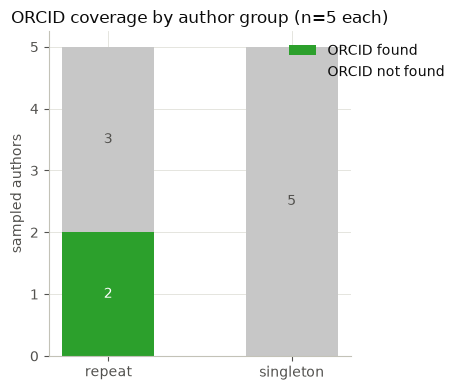

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
groups = ["repeat", "singleton"]
found_counts = [by_group.loc[g, "sum"] for g in groups]
not_found_counts = [by_group.loc[g, "count"] - by_group.loc[g, "sum"] for g in groups]

ax.bar(groups, found_counts, color=FOUND_COLOR, label="ORCID found", width=0.5)
ax.bar(groups, not_found_counts, bottom=found_counts, color=NOT_FOUND_COLOR,
       label="ORCID not found", width=0.5)

for i, g in enumerate(groups):
    total = by_group.loc[g, "count"]
    found = by_group.loc[g, "sum"]
    if found:
        ax.text(i, found / 2, str(int(found)), ha="center", va="center", color="white", fontsize=10)
    if total - found:
        ax.text(i, found + (total - found) / 2, str(int(total - found)), ha="center", va="center",
                color="#52514e", fontsize=10)

ax.set_ylabel("sampled authors")
ax.set_title("ORCID coverage by author group (n=5 each)")
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.35, 1))
plt.tight_layout()
plt.show()


## 7. Secondary read: does in-corpus repeat-count track ORCID total-works?

Only meaningful for the rows where an ORCID was actually resolved — with this few
points it's a qualitative read, not a correlation (don't oversell a trend from a
handful of authors).


In [9]:
resolved = sample_df[sample_df["orcid_found"]][
    ["author", "group", "in_corpus_n_papers", "orcid_total_works"]
].sort_values("orcid_total_works", ascending=False)
resolved


,author,group,in_corpus_n_papers,orcid_total_works
0,Karen Scrivener,repeat,15,131
4,Steve Albrecht,repeat,7,31


**Finding (judgement call, not a statistic):** with only a couple of resolved
authors, this is a qualitative read, not a correlation coefficient worth
computing. What's there is *directionally* consistent — the author with more
in-corpus papers also has the larger ORCID total-works count — but n this small
proves nothing on its own; it would take a much bigger resolved sample to call
this a real relationship.


## 8. Verdict: is this a viable feature?

- **Coverage found:** see §6's printed rate — this is the number that matters,
  not the two working examples used to scope the task.
- **Compounding ceiling at full scale (2,873 rows):** `doi` is filled on ~94% of
  the corpus; ORCID-on-Crossref coverage (this notebook's headline rate) then
  applies on top of that, so the two ceilings multiply rather than one setting
  the other's floor. A low resolution rate here means most rows would end up with
  a **missing** value for this feature, not a wrong one (NULL != 0, per this
  repo's own convention) — usable only as a sparse, optional feature, not a
  column every row can populate.
- **Cost to run at full scale:** both APIs are free and require no auth, so the
  cost is wall-clock and politeness, not money. Naively, one Crossref call per
  paper-author row plus one ORCID call per resolved iD, each with a ~0.5s
  courtesy delay, would take hours across thousands of rows serially — and would
  *redundantly* re-query the same repeat author once per paper unless calls are
  cached per unique author first (a real efficiency fix, not just a nice-to-have,
  given how skewed the author-frequency table is).
- **Caveat that stays true regardless of coverage:** an ORCID works-group count
  is a **total career** figure — it says nothing about how much of that output is
  relevant to *this* use case's topic. It's a "how established is this person"
  proxy, not a "how established are they in this field" one.
